# Exercises

_______

## 1) Derivative approximation

We consider the following real functions :

In [103]:
def f1(x):
    return 1 + x + x**2 - x**3

def f2(x):
    return x + x**2 - x**3

def f3(x):
    return ((1 + x)**2) ** 0.5

def f4(x):
    return abs(1+x)

### Questions
1. Plot the functions' graphs for $x\in [-1,1]$
2. Compute the reference derivatives
3. For $h\in [10^{-16}, 1]$ and each of the functions, plot the log-scale error of the approximated derivative at $x=0$ using the following techniques:
- a) Forward finite difference
- b) Centered finite difference
- c) Complex step
4. Interpret the results.

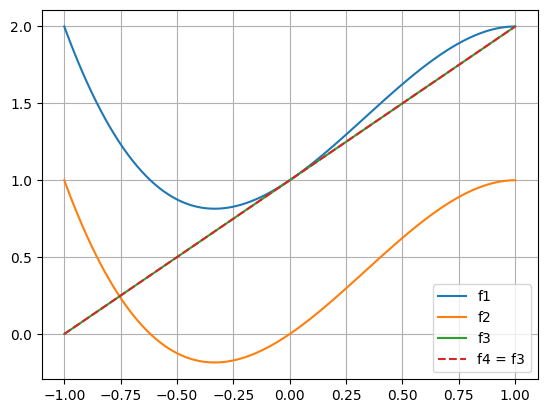

In [104]:
# Q1) Graph of the functions

import numpy as np
x = np.linspace(-1,1,100)

import matplotlib.pyplot as plt
plt.plot(x,f1(x), label = "f1")
plt.plot(x,f2(x), label = "f2")
plt.plot(x,f3(x), label = "f3")
plt.plot(x,f4(x), '--', label = "f4 = f3")
plt.legend(); plt.grid()
plt.show()

In [105]:
# Q2) Derivatives

def df1_dx(x):
    return - 3*x**2 + 2*x + 1

def df2_dx(x):
    return - 3*x**2 + 2*x + 1

def df3_dx(x):
    return (2*x + 2)/(2*((x + 1)**2)**0.5)


def df4_dx(x):
    return (2*x + 2)/(2*((x + 1)**2)**0.5)

In [106]:
# Q3) a Finite differences

def FD1(f, x, h):
    return ( f(x+h)-f(x) )/ h

def FD2(f, x, h):
    return ( f(x+h/2)-f(x-h/2) ) / h

def cplxStep(f, x, h):
    return (( f(x+ 1j*h))/ h).imag

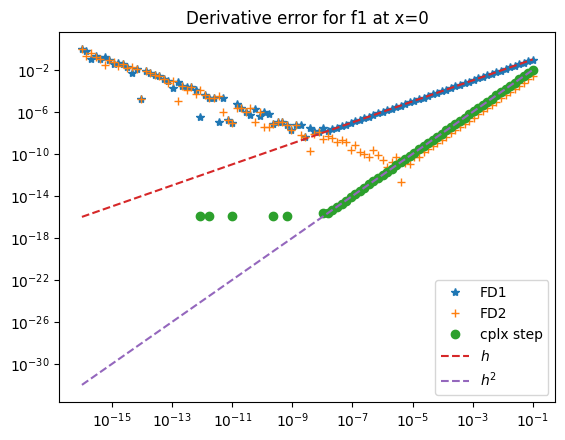

In [107]:
H = np.logspace(-16,-1,100)
plt.loglog(H, abs(FD1(f1, 0, H) - df1_dx(0)), '*', label = "FD1")
plt.loglog(H, abs(FD2(f1, 0, H) - df1_dx(0)), '+', label = "FD2")
plt.loglog(H, abs(cplxStep(f1, 0, H) - df1_dx(0)), 'o', label = "cplx step")
plt.loglog(H, H, '--', label = "$h$")
plt.loglog(H, H**2, '--', label = "$h^2$")
plt.legend(); plt.title("Derivative error for f1 at x=0")
plt.show()

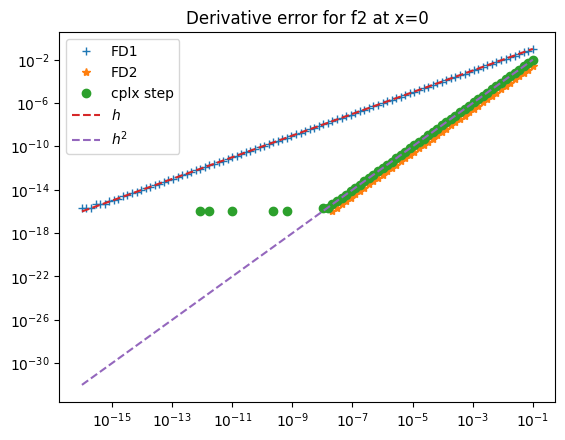

In [108]:
H = np.logspace(-16,-1,100)
plt.loglog(H, abs(FD1(f2, 0, H) - df2_dx(0)), '+', label = "FD1")
plt.loglog(H, abs(FD2(f2, 0, H) - df2_dx(0)), '*', label = "FD2")
plt.loglog(H, abs(cplxStep(f2, 0, H) - df2_dx(0)), 'o', label = "cplx step")
plt.loglog(H, H, '--', label = "$h$")
plt.loglog(H, H**2, '--', label = "$h^2$")
plt.legend(); plt.title("Derivative error for f2 at x=0")
plt.show()


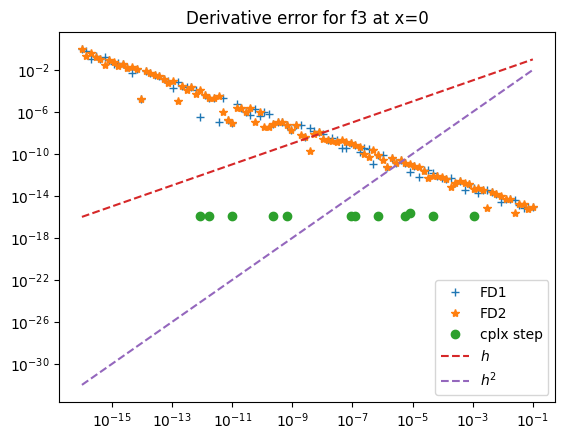

In [109]:
H = np.logspace(-16,-1,100)
plt.loglog(H, abs(FD1(f3, 0, H) - df3_dx(0)), '+', label = "FD1")
plt.loglog(H, abs(FD2(f3, 0, H) - df3_dx(0)), '*', label = "FD2")
plt.loglog(H, abs(cplxStep(f3, 0, H) - df3_dx(0)), 'o', label = "cplx step")
plt.loglog(H, H, '--', label = "$h$")
plt.loglog(H, H**2, '--', label = "$h^2$")
plt.legend(); plt.title("Derivative error for f3 at x=0")
plt.show()

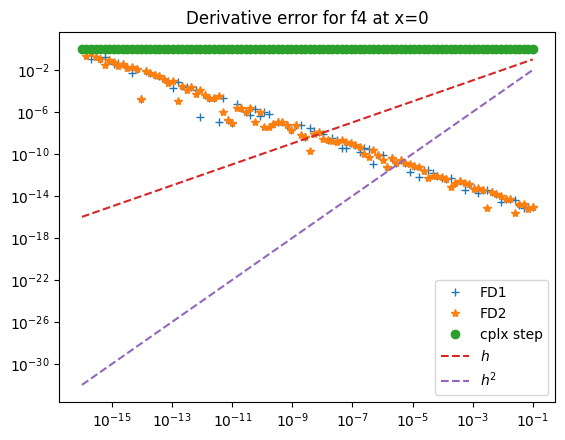

In [110]:
H = np.logspace(-16,-1,100)
plt.loglog(H, abs(FD1(f4, 0, H) - df4_dx(0)), '+', label = "FD1")
plt.loglog(H, abs(FD2(f4, 0, H) - df4_dx(0)), '*', label = "FD2")
plt.loglog(H, abs(cplxStep(f4, 0, H) - df4_dx(0)), 'o', label = "cplx step")
plt.loglog(H, H, '--', label = "$h$")
plt.loglog(H, H**2, '--', label = "$h^2$")
plt.legend(); plt.title("Derivative error for f4 at x=0")
plt.show()

**Interpretation** :
- $f_1$ is OK
- $f_2(0) = 0 $ so there is no cancellation error
- $f_3$ is linear so the finite differences are exact up to roundoff errors
- $f_4$ is equal to $f_3$ but is implemented using the absolute value, which is extended to the module for the complex number that is not an analytical function, so the complex step fails.

______
## 2) Solvers

We want to solve  $S(x) = Kx-F = 0$, which is linear but we don't want to use the matrix inverse.

### a) Fixed point

1. Write $S(x) = 0$ under the form $F(x) = x$
2. Try to solve the problem with a fixed point algorithm for $K = \begin{bmatrix} a, 0\\ 0, b \end{bmatrix}$ with $a,b >0$
3. Try to solve the problem with a fixed point for $K = \begin{bmatrix} a, 0\\ 0, b \end{bmatrix}$ with $a>0$ and $b<0$.
4. Interpretation?
5. Would Newton method, which is a special kind of fixed point, work on this problem?

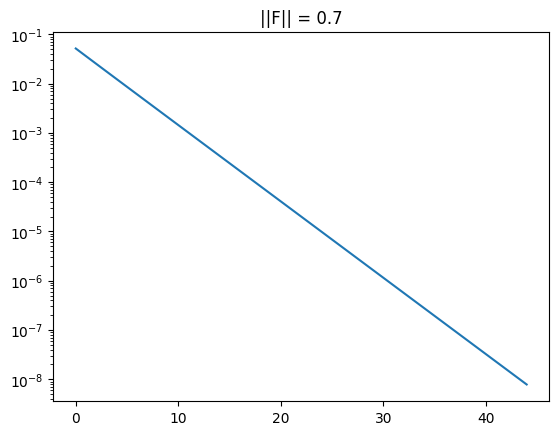

In [111]:
def fixedPoint(F, x0, maxit = 100, tol = 1e-8):
    x = [x0]
    for _ in range(maxit):
        x.append(F(x[-1]))
        if np.linalg.norm(x[-1]-x[-2]) < tol:
            break
    return x


th = np.random.rand()
R = np.array([[np.cos(th), -np.sin(th)],[np.sin(th), np.cos(th)]])

K = R @ np.array([[3,0],[0,4]]) @ R.T
f = np.random.rand(2)

S = lambda x: K @ x - f
a = 0.1
F = lambda X : X - a * S(X)
x0 = np.array([0,0])
F(x0)
x = fixedPoint(F, x0)
plt.semilogy([np.linalg.norm(x[i+1] - x[i]) for i in range(len(x)-1)])
plt.title(f"||F|| = {max(abs(np.linalg.eig(np.eye(2) - a*K)[0]))}")
plt.show()


### b) Newton

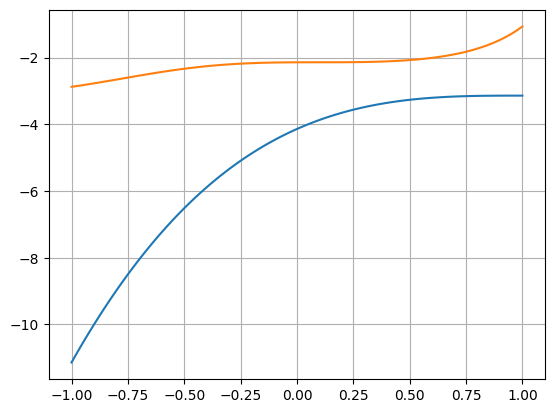

In [121]:
def f1(x):
    return (x-1)**3 - np.pi

def f2(x):
    return np.exp((x-0.1)**3) - np.pi

X = np.linspace(-1,1,100)
plt.plot(X, f1(X))
plt.plot(X,f2(X))
plt.grid()

In [ ]:
def naiveNewton(S, x0 = 0, maxit = 100, tol = 1e-8):
    x = [x0]
    for _ in range(maxit):
        d = -cplxStep(S, x[-1], h = 1e-50) * S(x[-1])
        x.append(x[-1] + d)
        if abs(S(x[-1]))<tol:
            break
    return x

def lineSearch_newton(residual, dresidual, B0,
           alpha = 0.5, s = 0.1, maxit_linesearch = 10,   # linesearch
           maxit = 100, rtol = 1e-8, atol = 1e-8   # stop criterion
           ):
     """ Newton method with Armijo's linesearch"""
     
     res2 = lambda B : residual(B)**2
     B = [B0]
     res0 = residual(B[0])
     k = 0 
     while abs(residual(B[-1])) > atol \
           and abs(residual(B[-1])/res0) > rtol \
           and k < maxit:
          
        # Descent direction
        d = - dresidual(B[-1]) ** (-1) * residual(B[-1]) ;  

        # Line search (Armijo backtracking)
        i = 0
        res2B = res2(B[-1])
        while res2(B[-1] + alpha ** i * d) >= ( 1 - 2*s*alpha ** i ) * res2B:
            if i>maxit_linesearch: 
                raise Exception("Linesearch has failed after {maxit_linesearch} iterations.")
            i += 1

        B.append(B[-1] +  alpha ** i * d)
        k += 1
        
     return np.array(B)


#xNewton1 = naiveNewton(f1, 0)
#plt.semilogy([abs(f1(xx)) for xx in xNewton1], 'o--', label = "naive")

xNewton2 = lineSearch_newton(f1, 0, tol = 1e-20)
plt.semilogy([abs(f1(xx)) for xx in xNewton2], 'o--', label = "linesearch")

plt.show()


3
2
4
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5


Exception: Linesearch has failed after 101 iterations.


- Newton with NaN 
- Newton with line search

______
## 3) Unconstrained optimization

- Gradient
- Newton
- Newton with bounds (doesn't work)

______
## 4) Constrained optimization

- projected gradient on a ball
- inductance problem